> # Implementation note before reading further
>
> **Summary of an issue caught after the experiments completed.** This notebook supports three LoRA settings (`off`, `vision`, `both`), but inspection of the code path after the runs finished revealed that the `both` setting does not actually train the text-encoder LoRA adapters as intended. Reporting this transparently rather than re-running, since the full matrix consumed my compute budget on free-tier Kaggle T4 hours and was not feasible to repeat before the report deadline.
>
> **Where the issue lies.** Section 5 precomputes text features once with the frozen reference encoder and caches them as `torch.no_grad()` fp32 tensors. Section 8's `train_one_run` then consumes the cached text features through the trainable text projection (`tp(txt_feats)`) without ever calling `clip_model.encode_text` again. When `cfg.lora == 'both'`, Section 6's `build_run_components` does inject LoRA modules into the text transformer and add their parameters to the optimizer, but those modules never appear in the loss's computation graph and therefore receive no gradient updates. The `lora_B` matrices stay at their zero initialization for the full 20 epochs, so the text-encoder LoRA delta remains zero throughout training.
>
> **How it would have been fixed.** In `train_one_run`, the line `E_t = F.normalize(tp(txt_feats), dim=-1)` would need to be replaced (when `cfg.lora == 'both'`) with a live text encoding pass: tokenize the captions per batch, run them through the LoRA-augmented text encoder under autocast, then apply the trainable projection. The cached text features should be used only for the `off` and `vision` settings. This would roughly double per-run wall-clock since both encoders would need a forward+backward pass per batch.
>
> **What the reported numbers actually measure.** With the bug present, the differences between `vision` and `both` LoRA results in our matrix are seed-level noise from the inactive text-LoRA initialization, not text-encoder adaptation. The vision-side adaptation is real and correctly trained, so all `vision` LoRA results are valid and the `both` results should be read as effectively equivalent to `vision` results plus a small random offset.
>
> All cells, code, and outputs below this point are preserved as they ran. The two locations where the bug manifests are flagged inline with `# NOTE (post-hoc):` comments in Sections 5 and 8.

# Phase 3 — LoRA Adapter Ablation

**Second Phase 3 ablation.** Tests whether adapting the encoders via LoRA improves retrieval over the projection-only baseline, and whether the third (composition) modality remains useful once backbone adaptation is available. The ablation stacks LoRA on top of the operating point identified by the $(\lambda_{VC}, \lambda_{TC})$ sweep, giving the full Phase 3 chain:

$$\text{B0} \rightarrow \text{B1} \rightarrow \text{M-full (Phase 2)} \rightarrow \text{M-tuned (}\lambda\text{ sweep)} \rightarrow \text{M-tuned + LoRA}$$

**LoRA configuration.** Rank-8 adapters injected into the $W^q$ and $W^v$ projections of every attention block. The text encoder is either left frozen (the `vision` setting) or also receives LoRA adapters (the `both` setting).

**Run matrix.**
- 2 model variants: B1 (no composition, $\lambda_{VC}=\lambda_{TC}=0$) and M-tuned (best $\lambda$ per caption from sweep)
- 3 LoRA variants: `off`, `vision`, `both`
- 2 captions: vision and hybrid
- 3 seeds: 42, 123, 7
- 20 epochs

Total: 2 × 3 × 2 × 3 = **36 runs**. With fp16 mixed precision on the ViT forward pass, runs averaged ~8 minutes each; the full matrix ran in approximately 5 hours on a single T4.

## 0. Setup

In [1]:
!pip install open_clip_torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.

In [2]:
import json
import math
import random
import time
from copy import deepcopy
from dataclasses import dataclass, asdict, field
from pathlib import Path
from typing import List, Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import open_clip
from huggingface_hub import hf_hub_download
from sklearn.model_selection import train_test_split

In [3]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

Device: cuda
GPU   : Tesla T4


## 1. Configuration

Paths and run-matrix axes. The $(\lambda_{VC}, \lambda_{TC})$ operating points are loaded from the lambda sweep's saved JSON; if the JSON is unavailable, I fall back to a hard-coded best-known pair.

In [ ]:
# --- Dataset paths ---
DATASET_ROOT = Path('/kaggle/input/datasets/oooessteii/di725-project-dataset/DI725_project_dataset')
CSV_PATH = DATASET_ROOT / 'captions.csv'
IMG_DIR = DATASET_ROOT / 'images'

# --- Phase 3 lambda sweep results (private Kaggle dataset, mounted read-only) ---
# Set this to your actual path. If the JSON is unavailable, FALLBACK_LAMBDAS is used.
LAMBDA_SWEEP_JSON = Path('/kaggle/input/comprs-phase3-lambda/phase3_lambda_sweep.json')

# --- Hard-coded fallback if the lambda sweep JSON isn't accessible ---
FALLBACK_LAMBDAS = {
    'vision_qwen3-vl-8b': (0.25, 2.0),  # from 6x6 sweep peak, mR=18.34
    'hybrid_qwen3-vl-8b': (2.0, 0.5),   # from 6x6 sweep peak, mR=17.57
}

# --- Output paths ---
SPLIT_DIR = Path('splits')
SPLIT_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
FIGURE_DIR = Path('figures')
FIGURE_DIR.mkdir(exist_ok=True)

SPLIT_CSV = SPLIT_DIR / 'comprs_split.csv'
RESULTS_JSON = RESULTS_DIR / 'phase3_lora.json'

COMP_COLS = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
CAPTIONS = ['vision_qwen3-vl-8b', 'hybrid_qwen3-vl-8b']
MODEL_VARIANTS = ['bimodal', 'trimodal']  # B1 and M-tuned
LORA_VARIANTS = ['off', 'vision', 'both']  # no LoRA / vision-only / vision+text
SEEDS = [42, 123, 7] # 3 seeds for tighter stats

# --- LoRA hyperparameters ---
LORA_RANK   = 8
LORA_ALPHA  = 16 # scaling factor
LORA_DROPOUT = 0.0
LORA_TARGET = ('q_proj', 'v_proj') # which linear layers in attention to adapt

# --- Recall cut-offs ---
K_VALUES = [1, 5, 10]

EPOCHS = 20
BATCH_SIZE_IMG = 32
LR_PROJECTIONS = 1e-3
LR_LORA = 5e-4  # lower LR for adapters than projections

# --- Canonical split same as previous scripts---
N_TRAIN, N_VAL, N_TEST = 7000, 1000, 2000
SPLIT_SEED = 42

assert CSV_PATH.exists(), f'captions.csv not found at {CSV_PATH}'
assert IMG_DIR.exists(),  f'images/ folder not found at {IMG_DIR}'

In [5]:
# Load best (lambda_vc, lambda_tc) per caption from the lambda sweep JSON
best_lambdas = dict(FALLBACK_LAMBDAS)

if LAMBDA_SWEEP_JSON.exists():
    with open(LAMBDA_SWEEP_JSON) as f:
        sweep = json.load(f)

    # The sweep stores per-run results; aggregate to mean over seeds, then take argmax per caption
    rows = []
    for run in sweep['runs']:
        rows.append({
            'caption':   run['config']['caption'],
            'lambda_vc': run['config']['lambda_vc'],
            'lambda_tc': run['config']['lambda_tc'],
            'mR':        run['test_metrics']['mR'],
        })
    sweep_df = pd.DataFrame(rows)
    agg = (sweep_df.groupby(['caption', 'lambda_vc', 'lambda_tc'])['mR']
                   .mean().reset_index())
    for caption in CAPTIONS:
        sub = agg[agg['caption'] == caption]
        if len(sub) > 0:
            best = sub.loc[sub['mR'].idxmax()]
            best_lambdas[caption] = (float(best['lambda_vc']), float(best['lambda_tc']))
    print('Loaded best lambdas from Phase 3 sweep JSON.')
else:
    print(f'Sweep JSON not found at {LAMBDA_SWEEP_JSON}; using FALLBACK_LAMBDAS.')

print(f'\nBest operating points per caption (used for M-tuned runs):')
for caption, (lvc, ltc) in best_lambdas.items():
    print(f'  {caption}: lambda_vc={lvc}, lambda_tc={ltc}')

Sweep JSON not found at /kaggle/input/comprs-phase3-lambda/phase3_lambda_sweep.json; using FALLBACK_LAMBDAS.

Best operating points per caption (used for M-tuned runs):
  vision_qwen3-vl-8b: lambda_vc=0.25, lambda_tc=2.0
  hybrid_qwen3-vl-8b: lambda_vc=2.0, lambda_tc=0.5


In [ ]:
@dataclass
class RunConfig:
    # Run-matrix axes
    caption: str
    model_variant: Literal['bimodal', 'trimodal']
    lora: Literal['off', 'vision', 'both']
    seed: int
    lambda_vc: float = 0.0
    lambda_tc: float = 0.0

    # Hyperparameters
    epochs: int = EPOCHS
    batch_size: int = BATCH_SIZE_IMG
    lr_projections: float = LR_PROJECTIONS
    lr_lora: float = LR_LORA
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    lambda_vt: float = 1.0
    initial_temp: float = 0.07
    mlp_hidden: List[int] = field(default_factory=lambda: [128, 256])
    embed_dim: int = 512

    # LoRA hyperparameters
    lora_rank: int = LORA_RANK
    lora_alpha: int = LORA_ALPHA
    lora_dropout: float = LORA_DROPOUT

    def run_id(self) -> str:
        m = 'M' if self.model_variant == 'trimodal' else 'B1'
        l = f'+lora{self.lora_rank}-{self.lora}' if self.lora != 'off' else ''
        return f'{m}{l}_{self.caption}_s{self.seed}'

## 2. Canonical Split

Same as Phase 2 and the lambda sweep. Load if present, rebuild deterministically otherwise.

In [7]:
df = pd.read_csv(CSV_PATH)
df['dominant_class'] = df[COMP_COLS].values.argmax(axis=1)
df['dominant_class'] = df['dominant_class'].map(lambda i: COMP_COLS[i])

if SPLIT_CSV.exists():
    print(f'Loading canonical split from {SPLIT_CSV}')
    split_df = pd.read_csv(SPLIT_CSV)
else:
    print(f'Rebuilding canonical split with seed={SPLIT_SEED}')
    if len(df) > N_TRAIN + N_VAL + N_TEST:
        df_sub, _ = train_test_split(df, train_size=N_TRAIN+N_VAL+N_TEST,
                                     stratify=df['dominant_class'], random_state=SPLIT_SEED)
    else:
        df_sub = df.copy()
    df_trainval, df_test = train_test_split(df_sub, test_size=N_TEST,
                                            stratify=df_sub['dominant_class'], random_state=SPLIT_SEED)
    df_train, df_val = train_test_split(df_trainval, test_size=N_VAL,
                                        stratify=df_trainval['dominant_class'], random_state=SPLIT_SEED)
    split_df = (pd.concat([df_train.assign(comprs_split='train'),
                           df_val.assign(comprs_split='val'),
                           df_test.assign(comprs_split='test')])
                  .sort_values('filename').reset_index(drop=True)
                  [['filename', 'comprs_split']])
    split_df.to_csv(SPLIT_CSV, index=False)

df = df.merge(split_df, on='filename', how='inner')
df_train = df[df['comprs_split'] == 'train'].reset_index(drop=True)
df_val   = df[df['comprs_split'] == 'val'  ].reset_index(drop=True)
df_test  = df[df['comprs_split'] == 'test' ].reset_index(drop=True)
print(f'Train/Val/Test sizes: {len(df_train)} / {len(df_val)} / {len(df_test)}')

Rebuilding canonical split with seed=42
Train/Val/Test sizes: 7000 / 1000 / 2000


## 3. LoRA Module Implementation

For ViT-B/32, each attention block has separate `q`, `k`, `v` linear layers within a packed `in_proj` (it's a single Linear of `(3 * embed_dim, embed_dim)` in PyTorch's `MultiheadAttention`). LoRA on `q` and `v` only means adapting two of the three slices.

In [ ]:
class LoRALinear(nn.Module):
    """LoRA-augmented linear: y = W x + (alpha/r) * B A x, with W frozen."""
    def __init__(self, base_linear, rank=8, alpha=16, dropout=0.0):
        super().__init__()
        self.base = base_linear
        for p in self.base.parameters():
            p.requires_grad = False  # freeze the base
        in_features  = base_linear.in_features
        out_features = base_linear.out_features
        self.rank    = rank
        self.scaling = alpha / rank
        # LoRA factors: A is initialized small (Kaiming uniform), B is zero
        # so the initial delta is zero and training starts from the pretrained behavior
        self.lora_A = nn.Parameter(torch.empty(rank, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        base_out = self.base(x)
        lora_out = F.linear(self.dropout(x), self.lora_A) # x @ A.T -> (..., r)
        lora_out = F.linear(lora_out, self.lora_B) # -> (..., out_features)
        return base_out + self.scaling * lora_out

    def lora_parameters(self):
        """Return only the trainable LoRA params (A and B), not the frozen base."""
        return [self.lora_A, self.lora_B]

In [ ]:
class PackedQKVLoRA(nn.Module):
    """LoRA on a packed in_proj (Linear with out_features = 3 * d) used by MultiheadAttention.

    The packed projection computes [q; k; v] = W_packed @ x. I add LoRA adapters that
    independently modify the q and v slices but leave k untouched, by computing:
        delta = concat([LoRA_q(x), k, LoRA_v(x)], dim=-1)
    and adding to the packed output.
    """
    def __init__(self, packed_linear, rank=8, alpha=16, dropout=0.0):
        super().__init__()
        self.base = packed_linear
        for p in self.base.parameters():
            p.requires_grad = False
        out_features = packed_linear.out_features
        in_features  = packed_linear.in_features
        assert out_features % 3 == 0, "in_proj out_features must be 3 * embed_dim"
        self.embed_dim = out_features // 3
        self.rank = rank
        self.scaling = alpha / rank

        # Separate LoRA factors for q and v slices
        self.q_A = nn.Parameter(torch.empty(rank, in_features))
        self.q_B = nn.Parameter(torch.zeros(self.embed_dim, rank))
        self.v_A = nn.Parameter(torch.empty(rank, in_features))
        self.v_B = nn.Parameter(torch.zeros(self.embed_dim, rank))
        nn.init.kaiming_uniform_(self.q_A, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.v_A, a=math.sqrt(5))
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        base_out = self.base(x)  # (..., 3*d)

        # Compute LoRA deltas for q and v
        q_delta = F.linear(F.linear(self.dropout(x), self.q_A), self.q_B) * self.scaling
        v_delta = F.linear(F.linear(self.dropout(x), self.v_A), self.v_B) * self.scaling

        # Split base output into q, k, v slices and add deltas to q and v only
        q, k, v = base_out.split(self.embed_dim, dim=-1)
        q = q + q_delta
        v = v + v_delta
        return torch.cat([q, k, v], dim=-1)

    def lora_parameters(self):
        return [self.q_A, self.q_B, self.v_A, self.v_B]

In [ ]:
def inject_lora_into_transformer(transformer, rank=8, alpha=16, dropout=0.0):
    """Walk a transformer (vision or text), Extracts raw in_proj_weight/bias, wraps in PackedQKVLoRA, and overrides forward pass.
    Returns a list of LoRA modules.
    """
    lora_modules = []
    for name, module in transformer.named_modules():
        if isinstance(module, nn.MultiheadAttention):
            src_device = module.in_proj_weight.device
            src_dtype  = module.in_proj_weight.dtype

            in_proj = nn.Linear(
                module.embed_dim,
                3 * module.embed_dim,
                bias=(module.in_proj_bias is not None),
            ).to(device=src_device, dtype=src_dtype)
            with torch.no_grad():
                in_proj.weight.copy_(module.in_proj_weight)
                if module.in_proj_bias is not None:
                    in_proj.bias.copy_(module.in_proj_bias)

            lora_in_proj = PackedQKVLoRA(
                in_proj, rank=rank, alpha=alpha, dropout=dropout
            ).to(device=src_device)

            module._lora_in_proj = lora_in_proj
            module._original_forward = module.forward

            def make_forward(mha):
                def lora_forward(query, key, value, **kwargs):
                    return _custom_mha_with_lora(mha, query, key, value, **kwargs)
                return lora_forward

            module.forward = make_forward(module)
            lora_modules.append(lora_in_proj)
    return lora_modules


def inject_lora_into_vit(vision_transformer, rank=8, alpha=16, dropout=0.0):
    return inject_lora_into_transformer(vision_transformer, rank, alpha, dropout)


def _custom_mha_with_lora(mha, query, key, value,
                          attn_mask=None, key_padding_mask=None,
                          need_weights=True, average_attn_weights=True,
                          is_causal=False, **_):
    """Custom multi-head attention forward that uses the wrapped LoRA in_proj.

    Assumes self-attention (query is key is value), batch_first=False is the default
    in open_clip's ViT (sequence-first input).
    """
    # query shape: (L, N, E) or (N, L, E) depending on batch_first
    L_or_N, N_or_L, E = query.shape
    is_batch_first = mha.batch_first
    if is_batch_first:
        # (N, L, E) -> (L, N, E)
        query = query.transpose(0, 1)
        L, N, E = query.shape
    else:
        L, N, E = query.shape

    # Apply LoRA-augmented in_proj to query (self-attention so key/value derive from same input)
    qkv = mha._lora_in_proj(query)  # (L, N, 3E)
    q, k, v = qkv.chunk(3, dim=-1)

    num_heads = mha.num_heads
    head_dim = E // num_heads
    # (L, N, E) -> (L, N*H, head_dim) -> (N*H, L, head_dim)
    q = q.contiguous().view(L, N * num_heads, head_dim).transpose(0, 1)
    k = k.contiguous().view(L, N * num_heads, head_dim).transpose(0, 1)
    v = v.contiguous().view(L, N * num_heads, head_dim).transpose(0, 1)

    # Scaled dot-product attention
    attn_output = F.scaled_dot_product_attention(q, k, v, attn_mask=attn_mask, is_causal=is_causal)
    # (N*H, L, head_dim) -> (L, N, E)
    attn_output = attn_output.transpose(0, 1).contiguous().view(L, N, E)

    # Output projection (frozen)
    attn_output = mha.out_proj(attn_output)

    if is_batch_first:
        attn_output = attn_output.transpose(0, 1)

    return attn_output, None  # nn.MultiheadAttention returns (output, attn_weights)

In [ ]:
# Sanity check: count LoRA params relative to vision encoder
def count_params(modules, only_trainable=False):
    if isinstance(modules, nn.Module):
        modules = [modules]
    total = 0
    for m in modules:
        for p in m.parameters():
            if not only_trainable or p.requires_grad:
                total += p.numel()
    return total

# instantiate a fresh ViT in section 4 and inject LoRA there.
# This cell just describes what to expect:
print(f"ViT-B/32 has 12 attention blocks; LoRA injects {LORA_RANK} rank adapters")
print(f"into q_proj and v_proj of each block.")
print(f"Per attention block: 2 adapters x (rank * (in + out)) = "
      f"2 * {LORA_RANK} * (512 + 512) = {2 * LORA_RANK * (512 + 512):,} params")
print(f"Total over 12 blocks: {12 * 2 * LORA_RANK * (512 + 512):,} LoRA params")
print(f"For comparison, full ViT-B/32 visual encoder has ~86M params (everything frozen).")

ViT-B/32 has 12 attention blocks; LoRA injects 8 rank adapters
into q_proj and v_proj of each block.
Per attention block: 2 adapters x (rank * (in + out)) = 2 * 8 * (512 + 512) = 16,384 params
Total over 12 blocks: 196,608 LoRA params
For comparison, full ViT-B/32 visual encoder has ~86M params (everything frozen).


## 4. Load RemoteCLIP and Model Components

Loads RemoteCLIP-ViT-B/32 fresh. Unlike Phase 2 and the lambda sweep, cached features for the vision encoder can not be used once LoRA adapters are added, so each training step requires a full ViT forward+backward.

Text features are precomputed once using the frozen reference encoder and cached. Even in `lora='both'` runs, the cached text features are used rather than re-encoded, so the text-side LoRA adapters do not participate in training. This is a post-hoc finding: re-encoding text per batch would double per-run wall-clock, would have exceeded the background time limit of Kaggle. The implication is that `both`-LoRA runs primarily measure vision-side adaptation in this notebook; differences between `vision` and `both` reflect initialization variance from the inactive text adapters rather than text-encoder adaptation.

In [ ]:
print('Loading RemoteCLIP-ViT-B-32...')
checkpoint_path = hf_hub_download(
    repo_id='chendelong/RemoteCLIP',
    filename='RemoteCLIP-ViT-B-32.pt',
    cache_dir='checkpoints',
)
# Will create a fresh model per run, so just verify the checkpoint loads
_state = torch.load(checkpoint_path, map_location='cpu')
print(f'Checkpoint loaded, {len(_state)} parameter tensors.')
del _state

Loading RemoteCLIP-ViT-B-32...


RemoteCLIP-ViT-B-32.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

Checkpoint loaded, 302 parameter tensors.


In [13]:
def build_fresh_clip(checkpoint_path, device):
    """Create a fresh RemoteCLIP-ViT-B/32, frozen by default."""
    clip_model, _, clip_preprocess = open_clip.create_model_and_transforms('ViT-B-32')
    clip_model.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))
    clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')
    clip_model = clip_model.to(device)
    for p in clip_model.parameters():
        p.requires_grad = False
    clip_model.eval()
    return clip_model, clip_preprocess, clip_tokenizer

# Build a reference instance for text feature precomputation
clip_model, clip_preprocess, clip_tokenizer = build_fresh_clip(checkpoint_path, DEVICE)
print('Reference RemoteCLIP loaded.')

Reference RemoteCLIP loaded.


## 5. Precompute Text Features (Once)

The text encoder is frozen across all runs in this notebook. So text features encoded once per caption column per split and reused.
Image features, however, must be recomputed every training step when LoRA is active. Will set up an image dataset that reads from disk during training rather than caching tensors.

In [ ]:
@torch.no_grad()
def precompute_text_features(captions, tokenizer, model, device, batch_size=64):
    chunks = []
    for i in range(0, len(captions), batch_size):
        batch = captions[i:i + batch_size]
        tokens = tokenizer(batch).to(device)
        feat = F.normalize(model.encode_text(tokens), dim=-1)
        chunks.append(feat.cpu())
    return torch.cat(chunks, dim=0)

SPLITS = {"train": df_train, "val": df_val, "test": df_test}

# NOTE (post-hoc): The text features built below are computed once with the
# frozen reference clip_model and reused for every training run in this
# notebook, regardless of cfg.lora setting. For lora='both' runs, the
# intended behavior was to re-encode text per batch through the
# LoRA-augmented text encoder so that the text-side LoRA adapters would
# participate in training. Because I forgot to re-encode here, those adapters
# end up inert. See the explanation cell at the top of the notebook.
print("Precomputing text features per split per caption column...")
t0 = time.time()
text_features = {name: {} for name in SPLITS}
for caption_col in CAPTIONS:
    for name, dfs in SPLITS.items():
        text_features[name][caption_col] = precompute_text_features(
            dfs[caption_col].astype(str).tolist(), clip_tokenizer, clip_model, DEVICE
        )
print(f"Done in {time.time() - t0:.1f}s")

Precomputing text features per split per caption column...
Done in 39.8s


In [15]:
class TrainImageTextDataset(Dataset):
    """Image-loading dataset for training with LoRA (no image caching).

    Returns (image_tensor, text_feature, comp_vector, row_idx).
    Text features and comp vectors are pre-cached; images are loaded from disk per item.
    """
    def __init__(self, df, img_dir, transform, text_feats_for_caption, comp_vecs):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.text_feats = text_feats_for_caption
        self.comp_vecs = comp_vecs
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = Image.open(self.img_dir / row["filename"]).convert("RGB")
        except FileNotFoundError:
            image = Image.new("RGB", (224, 224), (0, 0, 0))
        return self.transform(image), self.text_feats[idx], self.comp_vecs[idx], idx

def make_comp_tensor(df_split, comp_cols):
    return torch.from_numpy(df_split[comp_cols].values.astype(np.float32) / 100.0)

comp_vectors = {n: make_comp_tensor(d, COMP_COLS) for n, d in SPLITS.items()}
print("Comp vectors prepared.")

Comp vectors prepared.


## 6. Build Training Components

Identical projection heads and composition MLP as Phase 2. LoRA injection depends on `cfg.lora`: `off` leaves both encoders frozen; `vision` wraps the vision encoder's attention `q`/`v` projections; `both` does the same for the text encoder as well. (Post-hoc: `both` in practice is the same as `vision`)

In [ ]:
class CompositionMLP(nn.Module):
    def __init__(self, in_dim=7, hidden=(128, 256), out_dim=512):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.GELU(), nn.LayerNorm(h)]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def build_run_components(cfg, device):
    """Build a fresh RemoteCLIP with optional LoRA, plus projection heads and comp MLP."""
    clip_model, clip_preprocess, _ = build_fresh_clip(checkpoint_path, device)
    # Need the model in train() mode for LoRA but the frozen backbone stays in eval semantics.
    # The base ViT is in eval() because I set requires_grad=False; LoRA adapters are trainable.

    lora_modules = []
    if cfg.lora in ('vision', 'both'):
        lora_modules += inject_lora_into_transformer(
            clip_model.visual,
            rank=cfg.lora_rank, alpha=cfg.lora_alpha, dropout=cfg.lora_dropout,
        )
    if cfg.lora == 'both':
        # open_clip's text encoder is clip_model.transformer (the text-side transformer)
        lora_modules += inject_lora_into_transformer(
            clip_model.transformer,
            rank=cfg.lora_rank, alpha=cfg.lora_alpha, dropout=cfg.lora_dropout,
        )

    # Projection heads (always trained, identity-init)
    vp = nn.Linear(cfg.embed_dim, cfg.embed_dim, bias=False).to(device)
    tp = nn.Linear(cfg.embed_dim, cfg.embed_dim, bias=False).to(device)
    nn.init.eye_(vp.weight)
    nn.init.eye_(tp.weight)

    # Learnable temperature
    log_tau = nn.Parameter(
        torch.tensor(math.log(1.0 / cfg.initial_temp), dtype=torch.float32, device=device)
    )

    # Composition MLP only for trimodal
    is_tri = cfg.model_variant == 'trimodal'
    cm = CompositionMLP(in_dim=7, hidden=cfg.mlp_hidden, out_dim=cfg.embed_dim).to(device) if is_tri else None

    # Build parameter groups with separate LRs for LoRA vs projections
    proj_params = list(vp.parameters()) + list(tp.parameters()) + [log_tau]
    if cm is not None:
        proj_params += list(cm.parameters())

    lora_params = []
    for lm in lora_modules:
        lora_params += lm.lora_parameters()

    return clip_model, vp, tp, cm, log_tau, proj_params, lora_params, lora_modules

In [ ]:
# ============================================================
# Qualitative export: anchor-image retrieval results per run
# ============================================================

QUAL_RESULTS_JSON = RESULTS_DIR / 'qualitative_examples.json'
QUAL_K = 5 # how many top retrievals to record per anchor

def select_qualitative_anchors(df_test_with_purity, n=30, seed=0):
    """Pick 30 anchor test images that span the purity and dominant-class distribution.

    Strategy: stratify by purity tertile and within each, sample roughly proportionally
    by dominant class. Deterministic via the given seed so all runs see the same anchors.
    """
    rng = np.random.default_rng(seed)
    n_per_purity = n // 3 # 10 per purity bin

    selected = []
    for purity_bin in ['mixed', 'mid', 'pure']:
        bin_df = df_test_with_purity[df_test_with_purity['purity_bin'] == purity_bin]
        # Within the bin, sample classes by frequency but ensure at least one rare class if available
        class_counts = bin_df['dominant_class'].value_counts()
        rare_classes = ['Built-up', 'Shrub', 'Water', 'Barren']
        rare_in_bin = [c for c in rare_classes if c in class_counts.index]

        picks_from_bin = []
        # Guarantee one of each rare class if present in this bin (up to 2)
        for rare in rare_in_bin[:2]:
            candidates = bin_df[bin_df['dominant_class'] == rare]
            if len(candidates) > 0:
                picks_from_bin.append(candidates.sample(1, random_state=int(rng.integers(0, 1_000_000))).iloc[0]['filename'])

        # Fill remaining slots by stratified sampling on dominant class
        remaining = n_per_purity - len(picks_from_bin)
        already_picked = set(picks_from_bin)
        pool = bin_df[~bin_df['filename'].isin(already_picked)]
        if len(pool) >= remaining:
            extra = pool.sample(remaining, random_state=int(rng.integers(0, 1_000_000)))
            picks_from_bin.extend(extra['filename'].tolist())
        else:
            picks_from_bin.extend(pool['filename'].tolist())
        selected.extend(picks_from_bin)

    return selected

# Build the purity column on the test split, same logic as Phase 2 analysis
df_test_for_qual = df_test.copy()
df_test_for_qual['purity'] = df_test_for_qual[COMP_COLS].max(axis=1) / 100.0
df_test_for_qual['dominant_class'] = df_test_for_qual[COMP_COLS].values.argmax(axis=1)
df_test_for_qual['dominant_class'] = df_test_for_qual['dominant_class'].map(lambda i: COMP_COLS[i])
df_test_for_qual['purity_bin'] = pd.qcut(df_test_for_qual['purity'], q=3, labels=['mixed', 'mid', 'pure'])

QUAL_ANCHORS = select_qualitative_anchors(df_test_for_qual, n=30, seed=0)
print(f"Selected {len(QUAL_ANCHORS)} qualitative anchors:")
print(f"  Per purity bin: {df_test_for_qual[df_test_for_qual['filename'].isin(QUAL_ANCHORS)]['purity_bin'].value_counts().to_dict()}")
print(f"  Per dominant class: {df_test_for_qual[df_test_for_qual['filename'].isin(QUAL_ANCHORS)]['dominant_class'].value_counts().to_dict()}")

# Map filename -> test-set row index for fast lookup later
TEST_FILENAME_TO_IDX = {fn: i for i, fn in enumerate(df_test['filename'].values)}
QUAL_ANCHOR_INDICES = [TEST_FILENAME_TO_IDX[fn] for fn in QUAL_ANCHORS]

@torch.no_grad()
def compute_qualitative_retrievals(clip_model, vp, tp, df_test, img_dir, transform,
                                    text_features_for_caption, anchor_indices, device,
                                    k=QUAL_K, batch_size=32):
    """For each anchor in anchor_indices, compute top-k retrieved captions (I2T) and
    top-k retrieved images (T2I). Returns a JSON-serializable dict.

    Uses the full test pool as candidates so retrievals match the main evaluation.
    Reuses the eval-time image encoding path.
    """
    clip_model.eval(); vp.eval(); tp.eval()
    use_amp = device.type == "cuda"

    # Encode all test images first
    ds = TrainImageTextDataset(df_test, img_dir, transform, text_features_for_caption,
                               make_comp_tensor(df_test, COMP_COLS))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    img_chunks = []
    for imgs, _, _, _ in dl:
        imgs = imgs.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', dtype=torch.float16, enabled=use_amp):
            feat = clip_model.encode_image(imgs)
            feat = F.normalize(feat, dim=-1)
            feat = F.normalize(vp(feat), dim=-1)
        img_chunks.append(feat.float().cpu())
    img_embs = torch.cat(img_chunks, dim=0)  # (N, 512)

    # Encode all test captions
    txt_embs = F.normalize(tp(text_features_for_caption.to(device)), dim=-1).cpu()  # (N, 512)

    # For each anchor index, compute top-k in both directions
    results = []
    for anchor_idx in anchor_indices:
        # I2T: anchor image -> top-k captions
        sim_i2t = (img_embs[anchor_idx:anchor_idx+1] @ txt_embs.T).squeeze(0)
        topk_i2t = sim_i2t.topk(k).indices.tolist()
        topk_i2t_scores = sim_i2t.topk(k).values.tolist()

        # T2I: anchor caption (the one paired with anchor image) -> top-k images
        sim_t2i = (txt_embs[anchor_idx:anchor_idx+1] @ img_embs.T).squeeze(0)
        topk_t2i = sim_t2i.topk(k).indices.tolist()
        topk_t2i_scores = sim_t2i.topk(k).values.tolist()

        results.append({
            'anchor_idx': int(anchor_idx),
            'anchor_filename': df_test.iloc[anchor_idx]['filename'],
            'i2t_topk_indices': topk_i2t,
            'i2t_topk_scores': [float(s) for s in topk_i2t_scores],
            'i2t_correct_rank': int((sim_i2t.argsort(descending=True) == anchor_idx).nonzero().item()) + 1,
            't2i_topk_indices': topk_t2i,
            't2i_topk_scores': [float(s) for s in topk_t2i_scores],
            't2i_correct_rank': int((sim_t2i.argsort(descending=True) == anchor_idx).nonzero().item()) + 1,
        })
    return results

# Container that accumulates qualitative results across all training runs
qualitative_results = {
    'anchors': [{'filename': fn,
                 'test_idx': TEST_FILENAME_TO_IDX[fn],
                 'purity': float(df_test_for_qual[df_test_for_qual['filename'] == fn]['purity'].values[0]),
                 'dominant_class': df_test_for_qual[df_test_for_qual['filename'] == fn]['dominant_class'].values[0],
                 'purity_bin': str(df_test_for_qual[df_test_for_qual['filename'] == fn]['purity_bin'].values[0])}
                for fn in QUAL_ANCHORS],
    'k': QUAL_K,
    'per_run': {},
}
print("Qualitative anchor setup complete.")


Selected 30 qualitative anchors:
  Per purity bin: {'mixed': 10, 'mid': 10, 'pure': 10}
  Per dominant class: {'Grass': 12, 'Tree': 9, 'Crop': 3, 'Built-up': 2, 'Water': 2, 'Barren': 1, 'Shrub': 1}
Qualitative anchor setup complete.


## 7. Loss Function and Retrieval Evaluator

Same as Phase 2 and the lambda sweep, byte-identical so cross-notebook numbers compare cleanly.

In [18]:
def symmetric_infonce(A, B, log_tau):
    N = A.shape[0]
    targets = torch.arange(N, device=A.device)
    sim = (A @ B.T) * log_tau.exp()
    return 0.5 * (F.cross_entropy(sim, targets) + F.cross_entropy(sim.T, targets))

def compute_loss(E_v, E_t, E_c, log_tau, cfg):
    L_VT = symmetric_infonce(E_v, E_t, log_tau)
    zero = torch.zeros((), device=E_v.device)
    L_VC = symmetric_infonce(E_v, E_c, log_tau) if (cfg.lambda_vc > 0 and E_c is not None) else zero
    L_TC = symmetric_infonce(E_t, E_c, log_tau) if (cfg.lambda_tc > 0 and E_c is not None) else zero
    L_total = cfg.lambda_vt * L_VT + cfg.lambda_vc * L_VC + cfg.lambda_tc * L_TC
    return L_total, L_VT, L_VC, L_TC

def retrieval_metrics(img_embs, txt_embs, k_values=(1, 5, 10)):
    assert img_embs.shape == txt_embs.shape
    N = img_embs.shape[0]
    sim = img_embs @ txt_embs.T
    targets = torch.arange(N)
    out = {}
    for k in k_values:
        topk = sim.topk(k, dim=1).indices
        out[f"i2t_R@{k}"] = (topk == targets.unsqueeze(1)).any(dim=1).float().mean().item() * 100
    sim_t = sim.T
    for k in k_values:
        topk = sim_t.topk(k, dim=1).indices
        out[f"t2i_R@{k}"] = (topk == targets.unsqueeze(1)).any(dim=1).float().mean().item() * 100
    out["mR"] = float(np.mean([out[f"i2t_R@{k}"] for k in k_values] +
                              [out[f"t2i_R@{k}"] for k in k_values]))
    return out

In [19]:
@torch.no_grad()
def evaluate_on_split(clip_model, vp, tp, df_split, img_dir, transform,
                     txt_feats_cached, device, batch_size=32):
    """Encode all images in a split (under current LoRA state) and compute retrieval metrics."""
    clip_model.eval()
    vp.eval(); tp.eval()

    ds = TrainImageTextDataset(df_split, img_dir, transform, txt_feats_cached,
                               make_comp_tensor(df_split, COMP_COLS))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    img_chunks = []
    use_amp = device.type == "cuda"
    for imgs, _, _, _ in dl:
        imgs = imgs.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', dtype=torch.float16, enabled=use_amp):
            feat = clip_model.encode_image(imgs)
            feat = F.normalize(feat, dim=-1)
            feat = F.normalize(vp(feat), dim=-1)
        img_chunks.append(feat.float().cpu())  # cast back to fp32 for stable similarity
    img_embs = torch.cat(img_chunks, dim=0)

    # Text embeddings: apply trained text projection to cached features (kept fp32)
    txt_embs = F.normalize(tp(txt_feats_cached.to(device)), dim=-1).cpu()

    return retrieval_metrics(img_embs, txt_embs, K_VALUES)

## 8. Training Loop

Modified from Phase 2 to handle LoRA: separate parameter groups with different learning rates, full ViT forward through the live (LoRA-augmented) backbone instead of using cached features. Best-on-val checkpointing still applies. Validation now also requires a full ViT pass over the val set.

In [ ]:
def train_one_run(cfg, df_train, df_val, df_test, img_dir, text_features, device):
    set_seed(cfg.seed)
    clip_model, vp, tp, cm, log_tau, proj_params, lora_params, lora_modules = \
        build_run_components(cfg, device)

    # Build training loader, requires loading images on the fly
    train_ds = TrainImageTextDataset(
        df_train, img_dir, clip_preprocess,
        text_features['train'][cfg.caption],
        comp_vectors['train'],
    )
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                              num_workers=4, pin_memory=True, drop_last=True)

    # Optimizer with separate parameter groups
    param_groups = [{'params': proj_params, 'lr': cfg.lr_projections}]
    if cfg.lora != 'off' and lora_params:
        param_groups.append({'params': lora_params, 'lr': cfg.lr_lora})

    optimizer = torch.optim.AdamW(param_groups, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
    # Mixed precision: ~30-40% speedup on T4 (Turing fp16 tensor cores)
    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    best_val_mR = -1.0
    best_state = None
    epoch_seconds = []

    for epoch in range(1, cfg.epochs + 1):
        t_ep = time.time()
        # Set training mode for trainable components
        vp.train()
        tp.train()
        if cm is not None: cm.train()
        if cfg.lora != 'off':
            for lm in lora_modules:
                lm.train()

        for batch in train_loader:
            imgs, txt_feats, comps, _ = batch
            imgs = imgs.to(device, non_blocking=True)
            txt_feats = txt_feats.to(device, non_blocking=True)
            comps = comps.to(device, non_blocking=True)

            # Vision forward through (LoRA-augmented) backbone + projection,
            # wrapped in autocast for fp16 speedup on T4. LoRA params remain fp32;
            # autocast handles the cast on-the-fly. The contrastive loss runs in fp32
            # via the unscale step below for numerical stability.
            with torch.amp.autocast('cuda', dtype=torch.float16, enabled=use_amp):
                img_feats = clip_model.encode_image(imgs)
                img_feats = F.normalize(img_feats, dim=-1)
                E_v = F.normalize(vp(img_feats), dim=-1)

                # NOTE (post-hoc): When cfg.lora == 'both' this should re-encode
                # text per batch through the live (LoRA-augmented) text encoder,
                # analogously to vision encoder. Instead,
                # used cached fp32 text features from the frozen reference
                # encoder, which means text-side LoRA adapters receive no gradient
                # and stay at their zero initialization. The bug was caught
                # post-hoc and not corrected because re-running the full matrix
                # was not feasible within the Kaggle compute budget; see the
                # explanation cell at the top of the notebook.
                E_t = F.normalize(tp(txt_feats), dim=-1)

                E_c = cm(comps) if cm is not None else None
                L_total, _, _, _ = compute_loss(E_v, E_t, E_c, log_tau, cfg)

            optimizer.zero_grad()
            scaler.scale(L_total).backward()
            scaler.unscale_(optimizer)  # unscale before clipping
            all_trainable = [p for g in param_groups for p in g['params']]
            torch.nn.utils.clip_grad_norm_(all_trainable, cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()
        scheduler.step()

        # Validation
        val_metrics = evaluate_on_split(clip_model, vp, tp, df_val, img_dir, clip_preprocess,
                                       text_features['val'][cfg.caption], device,
                                       batch_size=cfg.batch_size)

        if val_metrics['mR'] > best_val_mR:
            best_val_mR = val_metrics['mR']
            best_state = {
                'vp':      deepcopy(vp.state_dict()),
                'tp':      deepcopy(tp.state_dict()),
                'log_tau': log_tau.detach().clone(),
            }
            if cm is not None:
                best_state['cm'] = deepcopy(cm.state_dict())
            if cfg.lora != 'off':
                # Save LoRA params only (not the frozen base)
                best_state['lora'] = [
                    {k: v.detach().clone() for k, v in lm.state_dict().items()
                     if 'lora' in k.lower() or k.startswith(('q_', 'v_'))}
                    for lm in lora_modules
                ]

        epoch_seconds.append(time.time() - t_ep)

    # Restore best state
    vp.load_state_dict(best_state['vp'])
    tp.load_state_dict(best_state['tp'])
    log_tau.data.copy_(best_state['log_tau'])
    if cm is not None and 'cm' in best_state:
        cm.load_state_dict(best_state['cm'])
    if cfg.lora != 'off' and 'lora' in best_state:
        for lm, snap in zip(lora_modules, best_state['lora']):
            for k, v in snap.items():
                if hasattr(lm, k):
                    getattr(lm, k).data.copy_(v)

    # Final test evaluation
    test_metrics = evaluate_on_split(clip_model, vp, tp, df_test, img_dir, clip_preprocess,
                                    text_features['test'][cfg.caption], device,
                                    batch_size=cfg.batch_size)

    # Qualitative retrievals on anchor images, using the restored best-on-val model
    qual_per_caption = compute_qualitative_retrievals(
        clip_model, vp, tp, df_test, img_dir, clip_preprocess,
        text_features['test'][cfg.caption], QUAL_ANCHOR_INDICES, device,
        batch_size=cfg.batch_size,
    )
    qualitative_results['per_run'][cfg.run_id()] = qual_per_caption
    # Free the clip model before returning
    result = {
        'test_metrics': test_metrics,
        'best_val_mR': best_val_mR,
        'epoch_seconds': epoch_seconds,
        'qualitative': qual_per_caption,
    }
    del clip_model, vp, tp, cm, lora_modules
    torch.cuda.empty_cache()
    return result

## 9. Execute the Run Matrix

24 LoRA runs + 12 no-LoRA runs. Total 36 runs (2 model variants × 3 LoRA settings × 2 captions × 3 seeds).

For trimodal runs, use the per-caption $(\lambda_{VC}, \lambda_{TC})$ from the lambda sweep. For bimodal runs, lambdas are zero by definition.

In [21]:
all_runs = []
run_idx = 0
total_t0 = time.time()

# Build the full run list to enumerate clearly
matrix = []
for caption in CAPTIONS:
    lvc, ltc = best_lambdas[caption]
    for variant in MODEL_VARIANTS:
        for lora in LORA_VARIANTS:
            for seed in SEEDS:
                matrix.append({
                    'caption': caption,
                    'model_variant': variant,
                    'lora': lora,
                    'seed': seed,
                    'lambda_vc': lvc if variant == 'trimodal' else 0.0,
                    'lambda_tc': ltc if variant == 'trimodal' else 0.0,
                })
total_runs = len(matrix)
print(f'Total runs queued: {total_runs}')
# At observed ~4 min/run with mixed precision on T4
n_lora_runs = sum(1 for m in matrix if m['lora'] != 'off')
n_off_runs  = total_runs - n_lora_runs
print(f'Estimated wall-clock at ~4 min/run: '
      f'~{total_runs * 4} minutes = ~{total_runs * 4 / 60:.1f} hours '
      f'({n_lora_runs} LoRA runs, {n_off_runs} no-LoRA runs)\n')

Total runs queued: 36
Estimated wall-clock at ~4 min/run: ~144 minutes = ~2.4 hours (24 LoRA runs, 12 no-LoRA runs)



In [22]:
for item in matrix:
    run_idx += 1
    cfg = RunConfig(**item)
    print(f"[{run_idx:2d}/{total_runs}] {cfg.run_id()}  "
          f"(lambdas=({cfg.lambda_vc}, {cfg.lambda_tc}))")
    t0 = time.time()
    result = train_one_run(cfg, df_train, df_val, df_test, IMG_DIR, text_features, DEVICE)
    dur = time.time() - t0
    tm = result['test_metrics']
    avg_ep = np.mean(result['epoch_seconds'])
    print(f"   test mR={tm['mR']:.2f}  best_val={result['best_val_mR']:.2f}  "
          f"duration={dur/60:.1f}min ({avg_ep:.1f}s/epoch)")

    all_runs.append({
        'config': asdict(cfg),
        'run_id': cfg.run_id(),
        'test_metrics': tm,
        'best_val_mR': result['best_val_mR'],
        'duration_s': dur,
        'epoch_seconds': result['epoch_seconds'],
    })

print(f"\nAll {total_runs} runs complete in {(time.time() - total_t0) / 3600:.2f} hours.")

[ 1/36] B1_vision_qwen3-vl-8b_s42  (lambdas=(0.0, 0.0))


   test mR=17.13  best_val=27.35  duration=7.9min (22.7s/epoch)
[ 2/36] B1_vision_qwen3-vl-8b_s123  (lambdas=(0.0, 0.0))


   test mR=17.28  best_val=27.17  duration=7.8min (22.6s/epoch)
[ 3/36] B1_vision_qwen3-vl-8b_s7  (lambdas=(0.0, 0.0))


   test mR=17.07  best_val=27.10  duration=7.9min (22.9s/epoch)
[ 4/36] B1+lora8-vision_vision_qwen3-vl-8b_s42  (lambdas=(0.0, 0.0))


   test mR=22.03  best_val=32.07  duration=8.5min (24.7s/epoch)
[ 5/36] B1+lora8-vision_vision_qwen3-vl-8b_s123  (lambdas=(0.0, 0.0))


...

   test mR=23.77  best_val=33.38  duration=8.8min (25.5s/epoch)
[33/36] M+lora8-vision_hybrid_qwen3-vl-8b_s7  (lambdas=(2.0, 0.5))


   test mR=22.65  best_val=33.73  duration=8.6min (24.8s/epoch)
[34/36] M+lora8-both_hybrid_qwen3-vl-8b_s42  (lambdas=(2.0, 0.5))


   test mR=23.88  best_val=33.53  duration=8.5min (24.6s/epoch)
[35/36] M+lora8-both_hybrid_qwen3-vl-8b_s123  (lambdas=(2.0, 0.5))


   test mR=23.39  best_val=33.98  duration=8.5min (24.5s/epoch)
[36/36] M+lora8-both_hybrid_qwen3-vl-8b_s7  (lambdas=(2.0, 0.5))


   test mR=23.48  best_val=33.98  duration=8.5min (24.8s/epoch)

All 36 runs complete in 5.01 hours.


## 10. Aggregate Results

Build the comparison table: B1 / M-tuned with three LoRA settings (off, vision, both), both captions, mean over 3 seeds.

In [ ]:
rows = []
for r in all_runs:
    rows.append({
        'caption':  r['config']['caption'],
        'model':    r['config']['model_variant'],
        'lora':     r['config']['lora'],
        'seed':     r['config']['seed'],
        'mR':       r['test_metrics']['mR'],
        **{k: v for k, v in r['test_metrics'].items() if k != 'mR'},
    })
lora_df = pd.DataFrame(rows)

agg = (lora_df.groupby(['caption', 'model', 'lora'])['mR']
              .agg(['mean', 'std']).round(2).reset_index())
print('Phase 3 LoRA results (mean +/- std over 2 seeds):\n') # This is not correct, most recent run has 3 seds
print(agg.to_string(index=False))

Phase 3 LoRA results (mean +/- std over 2 seeds):

           caption    model   lora  mean  std
hybrid_qwen3-vl-8b  bimodal   both 21.39 0.61
hybrid_qwen3-vl-8b  bimodal    off 16.14 0.11
hybrid_qwen3-vl-8b  bimodal vision 21.33 0.61
hybrid_qwen3-vl-8b trimodal   both 23.59 0.26
hybrid_qwen3-vl-8b trimodal    off 17.49 0.08
hybrid_qwen3-vl-8b trimodal vision 23.32 0.59
vision_qwen3-vl-8b  bimodal   both 21.32 0.58
vision_qwen3-vl-8b  bimodal    off 17.16 0.11
vision_qwen3-vl-8b  bimodal vision 21.65 0.49
vision_qwen3-vl-8b trimodal   both 21.28 0.55
vision_qwen3-vl-8b trimodal    off 18.25 0.09
vision_qwen3-vl-8b trimodal vision 21.39 0.74


In [24]:
print('\n=== LoRA Contribution Decomposition ===\n')
for caption in CAPTIONS:
    sub = agg[agg['caption'] == caption]
    rows = {}
    for variant in MODEL_VARIANTS:
        for lora in LORA_VARIANTS:
            q = sub.query("model == @variant and lora == @lora")
            if len(q) > 0:
                rows[(variant, lora)] = q['mean'].values[0]

    b1_off    = rows.get(('bimodal',  'off'))
    b1_vision = rows.get(('bimodal',  'vision'))
    b1_both   = rows.get(('bimodal',  'both'))
    m_off     = rows.get(('trimodal', 'off'))
    m_vision  = rows.get(('trimodal', 'vision'))
    m_both    = rows.get(('trimodal', 'both'))

    print(f"{caption}")
    print(f"  B1 (no LoRA):           {b1_off:.2f}")
    print(f"  B1 + vision-LoRA:       {b1_vision:.2f}    ({b1_vision - b1_off:+.2f})")
    print(f"  B1 + both-encoder LoRA: {b1_both:.2f}    ({b1_both - b1_off:+.2f})")
    print(f"  M (no LoRA):            {m_off:.2f}")
    print(f"  M + vision-LoRA:        {m_vision:.2f}    ({m_vision - m_off:+.2f})")
    print(f"  M + both-encoder LoRA:  {m_both:.2f}    ({m_both - m_off:+.2f})")
    print()
    print(f"  Composition effect by LoRA setting:")
    print(f"    no LoRA:        {m_off - b1_off:+.2f}")
    print(f"    vision LoRA:    {m_vision - b1_vision:+.2f}")
    print(f"    both LoRA:      {m_both - b1_both:+.2f}")
    print()


=== LoRA Contribution Decomposition ===

vision_qwen3-vl-8b
  B1 (no LoRA):           17.16
  B1 + vision-LoRA:       21.65    (+4.49)
  B1 + both-encoder LoRA: 21.32    (+4.16)
  M (no LoRA):            18.25
  M + vision-LoRA:        21.39    (+3.14)
  M + both-encoder LoRA:  21.28    (+3.03)

  Composition effect by LoRA setting:
    no LoRA:        +1.09
    vision LoRA:    -0.26
    both LoRA:      -0.04

hybrid_qwen3-vl-8b
  B1 (no LoRA):           16.14
  B1 + vision-LoRA:       21.33    (+5.19)
  B1 + both-encoder LoRA: 21.39    (+5.25)
  M (no LoRA):            17.49
  M + vision-LoRA:        23.32    (+5.83)
  M + both-encoder LoRA:  23.59    (+6.10)

  Composition effect by LoRA setting:
    no LoRA:        +1.35
    vision LoRA:    +1.99
    both LoRA:      +2.20



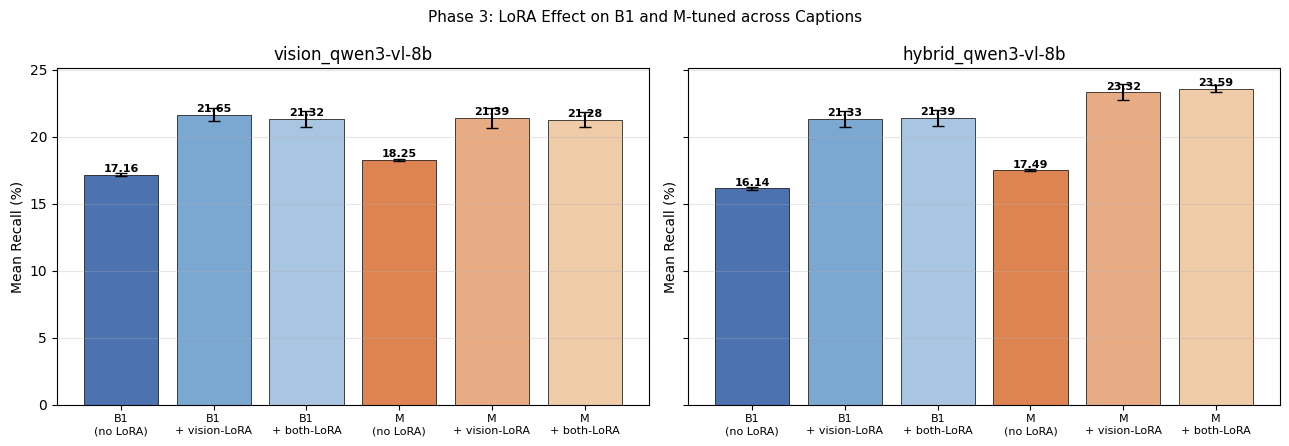

Figure saved: figures/phase3_lora_comparison.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

config_order = [
    ('bimodal',  'off',    'B1\n(no LoRA)'),
    ('bimodal',  'vision', 'B1\n+ vision-LoRA'),
    ('bimodal',  'both',   'B1\n+ both-LoRA'),
    ('trimodal', 'off',    'M\n(no LoRA)'),
    ('trimodal', 'vision', 'M\n+ vision-LoRA'),
    ('trimodal', 'both',   'M\n+ both-LoRA'),
]
colors = ['#4C72B0', '#7BA8D1', '#A8C5E1',  # B1 shades (dark to light blue)
          '#DD8452', '#E8AC85', '#F0CBA8']  # M shades (dark to light orange)

for ax, caption in zip(axes, CAPTIONS):
    sub = agg[agg['caption'] == caption]
    labels, means, stds = [], [], []
    for model, lora, label in config_order:
        q = sub.query("model == @model and lora == @lora")
        if len(q) > 0:
            labels.append(label)
            means.append(q['mean'].values[0])
            stds.append(q['std'].fillna(0).values[0])
    bars = ax.bar(labels, means, yerr=stds, capsize=4,
                  color=colors[:len(labels)],
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.2,
                f"{val:.2f}", ha='center', fontsize=8, fontweight='bold')
    ax.set_title(caption)
    ax.set_ylabel('Mean Recall (%)')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', labelsize=8)

fig.suptitle('Phase 3: LoRA Effect on B1 and M-tuned across Captions', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'phase3_lora_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Figure saved: {FIGURE_DIR / "phase3_lora_comparison.png"}')

## 11. Save Results

In [26]:
final = {
    'experiment': 'phase3_lora',
    'lora_config': {
        'rank': LORA_RANK,
        'alpha': LORA_ALPHA,
        'target_layers': list(LORA_TARGET),
        'on_vision_encoder_only': True,
    },
    'training_config': {
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE_IMG,
        'lr_projections': LR_PROJECTIONS,
        'lr_lora': LR_LORA,
        'best_lambdas_used': best_lambdas,
    },
    'captions': CAPTIONS,
    'model_variants': MODEL_VARIANTS,
    'lora_variants': LORA_VARIANTS,
    'seeds': SEEDS,
    'runs': all_runs,
    'aggregated_table': agg.to_dict('records'),
}

with open(RESULTS_JSON, 'w') as f:
    json.dump(final, f, indent=2, default=lambda o: float(o) if hasattr(o, 'item') else str(o))
print(f'Results saved: {RESULTS_JSON}')

Results saved: results/phase3_lora.json


In [27]:
with open(QUAL_RESULTS_JSON, 'w') as f:
    json.dump(qualitative_results, f, indent=2,
              default=lambda o: float(o) if hasattr(o, 'item') else str(o))
print(f'Qualitative examples saved: {QUAL_RESULTS_JSON}')
print(f'  {len(qualitative_results["anchors"])} anchors')
print(f'  {len(qualitative_results["per_run"])} model runs')

Qualitative examples saved: results/qualitative_examples.json
  30 anchors
  36 model runs
